Cuando trabajás con datos tabulares, Pandas y NumPy se integran de manera natural con Matplotlib. Podés graficar directamente desde DataFrames, preparar series temporales y realizar cálculos vectorizados con NumPy sin perder la API orientada a objetos de Matplotlib.

9.1 Graficar directamente DataFrames de Pandas
Pandas usa Matplotlib como backend de visualización. Es posible llamar a DataFrame.plot() o Series.plot() pasando un objeto Axes para mantener el control OO.

Line plot y bar plot desde un DataFrame

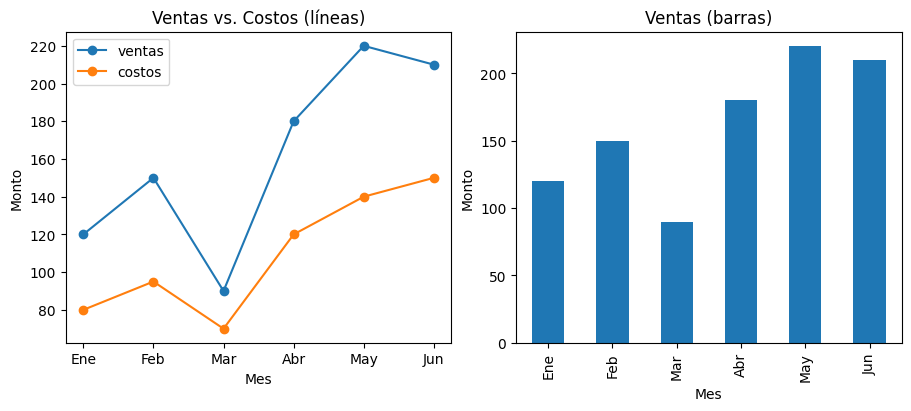

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Datos de ejemplo
df = pd.DataFrame({
    "mes": ["Ene", "Feb", "Mar", "Abr", "May", "Jun"],
    "ventas": [120, 150, 90, 180, 220, 210],
    "costos": [80, 95, 70, 120, 140, 150],
}).set_index("mes")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), layout="constrained")

df.plot(ax=ax1, marker="o")
ax1.set_title("Ventas vs. Costos (líneas)")
ax1.set_xlabel("Mes")
ax1.set_ylabel("Monto")

df["ventas"].plot(kind="bar", ax=ax2)
ax2.set_title("Ventas (barras)")
ax2.set_xlabel("Mes")
ax2.set_ylabel("Monto")

plt.show()

Gráficos por grupo (groupby) y subplots

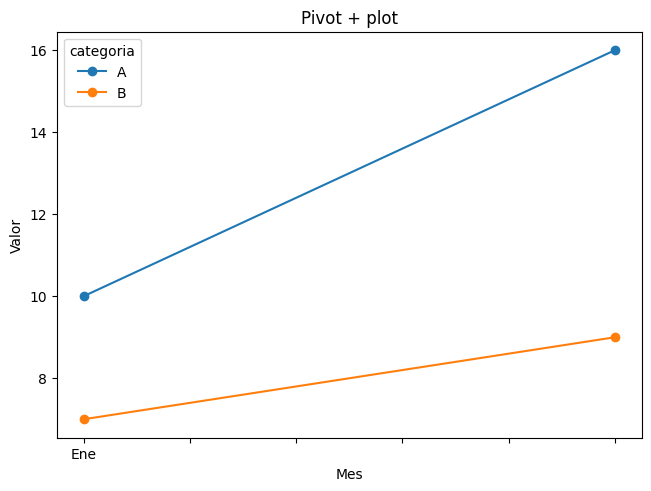

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

datos = [
    {"categoria": "A", "mes": "Ene", "valor": 10},
    {"categoria": "A", "mes": "Feb", "valor": 16},
    {"categoria": "B", "mes": "Ene", "valor": 7},
    {"categoria": "B", "mes": "Feb", "valor": 9},
]
df = pd.DataFrame(datos)

pivot = df.pivot(index="mes", columns="categoria", values="valor")
fig, ax = plt.subplots(layout="constrained")
pivot.plot(ax=ax, marker="o")
ax.set_title("Pivot + plot")
ax.set_xlabel("Mes")
ax.set_ylabel("Valor")
plt.show()

Series temporales con DatetimeIndex

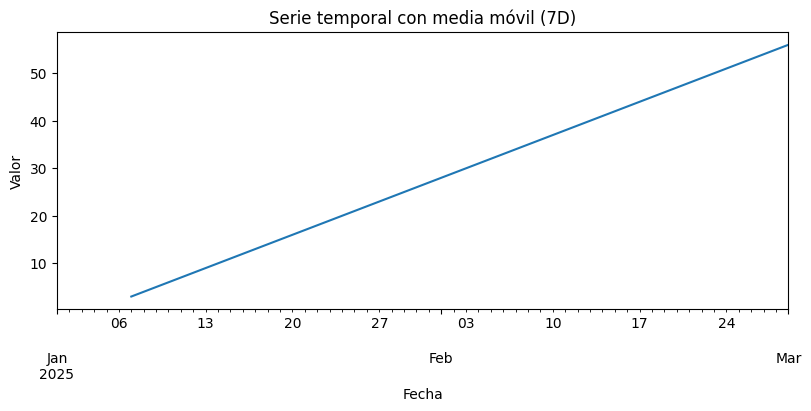

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

rng = pd.date_range("2025-01-01", periods=60, freq="D")
serie = pd.Series(range(60), index=rng).rolling(7).mean()

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
serie.plot(ax=ax)
ax.set_title("Serie temporal con media móvil (7D)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Valor")
plt.show()

📝 Pasá siempre ax= al graficar con Pandas para evitar mezclar estado global.

9.2 Integración con NumPy
NumPy es la base de las Series y DataFrames de Pandas. Podés mover datos de un lado a otro según convenga.

Graficar arrays NumPy en Axes

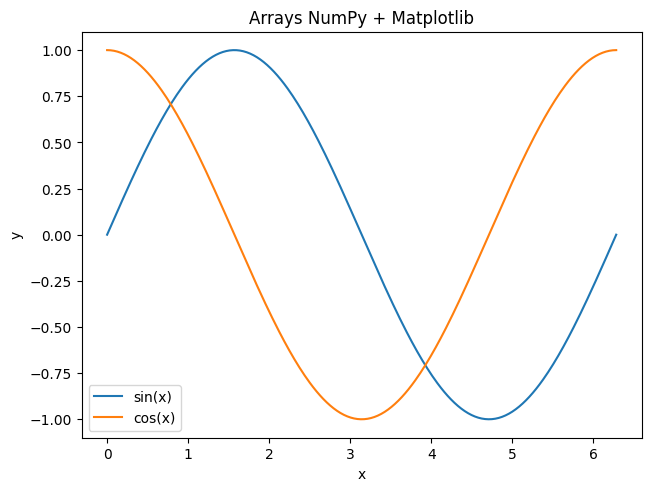

In [4]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 2 * np.pi, 300)
y1 = np.sin(x)
y2 = np.cos(x)

fig, ax = plt.subplots(layout="constrained")
ax.plot(x, y1, label="sin(x)")
ax.plot(x, y2, label="cos(x)")
ax.set_title("Arrays NumPy + Matplotlib")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()

Calcular con NumPy y almacenar en Pandas

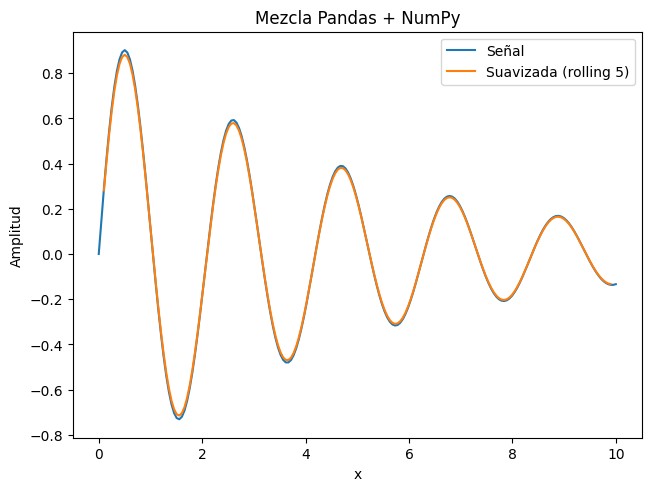

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

x = np.linspace(0, 10, 200)
signal = np.exp(-0.2 * x) * np.sin(3 * x)

df = pd.DataFrame({"x": x, "signal": signal})
df["suavizada"] = pd.Series(signal).rolling(5, center=True).mean()

fig, ax = plt.subplots(layout="constrained")
ax.plot(df["x"], df["signal"], label="Señal")
ax.plot(df["x"], df["suavizada"], label="Suavizada (rolling 5)")
ax.set_title("Mezcla Pandas + NumPy")
ax.set_xlabel("x")
ax.set_ylabel("Amplitud")
ax.legend()
plt.show()

De DataFrame a NumPy para vectorizar

In [6]:
import numpy as np

v = df["signal"].to_numpy()
df["abs_signal"] = np.abs(v)

9.3 Ejemplo práctico con Titanic
Cargamos el dataset Titanic desde Seaborn, lo convertimos en un DataFrame de Pandas y generamos gráficos con Matplotlib manteniendo la API orientada a objetos.

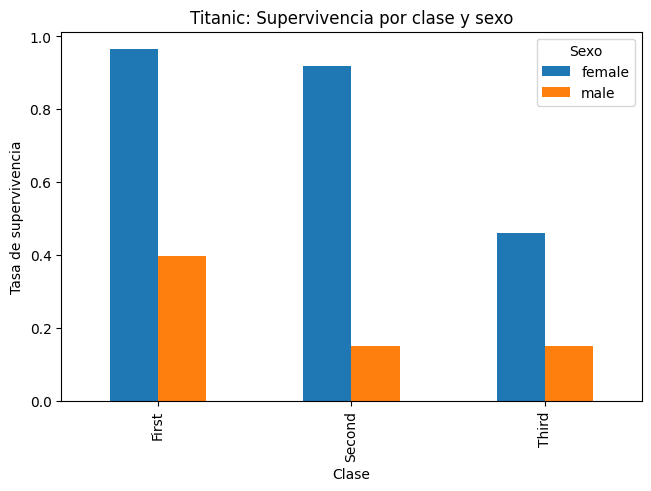

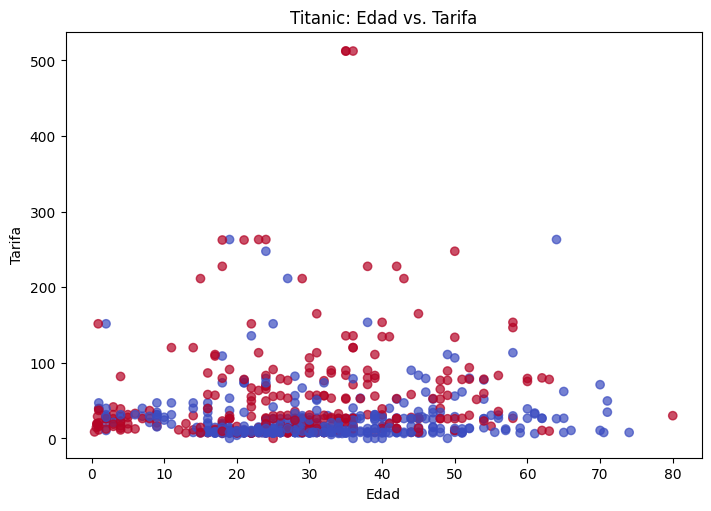

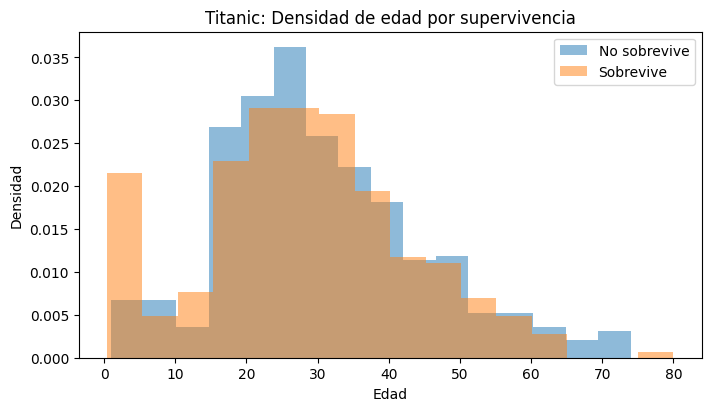

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1) Cargar y preparar datos
Titanic = sns.load_dataset("titanic")
Titanic = Titanic[["survived", "class", "sex", "age", "fare"]].dropna()

# 2) Tasa de supervivencia por clase y sexo
fig, ax = plt.subplots(layout="constrained")
survival_rate = Titanic.groupby(["class", "sex"])["survived"].mean().unstack()
survival_rate.plot(kind="bar", ax=ax)
ax.set_title("Titanic: Supervivencia por clase y sexo")
ax.set_xlabel("Clase")
ax.set_ylabel("Tasa de supervivencia")
ax.legend(title="Sexo")
plt.show()

# 3) Dispersión: edad vs. tarifa (fare)
fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
ax.scatter(Titanic["age"], Titanic["fare"], c=Titanic["survived"], cmap="coolwarm", alpha=0.7)
ax.set_title("Titanic: Edad vs. Tarifa")
ax.set_xlabel("Edad")
ax.set_ylabel("Tarifa")
plt.show()

# 4) Histogramas de edad por supervivencia
fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
for survived, subset in Titanic.groupby("survived"):
    etiqueta = "Sobrevive" if survived == 1 else "No sobrevive"
    ax.hist(subset["age"], bins="auto", alpha=0.5, density=True, label=etiqueta)
ax.set_title("Titanic: Densidad de edad por supervivencia")
ax.set_xlabel("Edad")
ax.set_ylabel("Densidad")
ax.legend()
plt.show()

💡 El mismo flujo se puede adaptar a otros archivos CSV con pd.read_csv manteniendo la estructura de figuras y ejes.

Buenas prácticas (Pandas + NumPy + Matplotlib)
Mantené la API orientada a objetos: definí fig, ax = plt.subplots() y pasá ax= a df.plot().
Usá nombres de columnas claros; se reutilizan como ejes y leyendas.
Para series temporales, aprovechá DatetimeIndex y formateo automático de ticks.
Prepará los datos con groupby, pivot, rolling o resample antes de graficar.
Evitá mezclar llamadas a plt.* sin ax cuando trabajás con varios subplots.
Usá .to_numpy() o np.asarray() para cálculos vectorizados pesados.